# Comparaison avec des méthodes d'ensemble
### Scoring de risque de crédit — Séance 7

On repart du résultat de S6 (train/test, standardisation, régression logistique). On reconstitue rapidement le pipeline des séances précédentes, puis on entraîne et compare Random Forest et Gradient Boosting à la régression logistique.

## Étape 0 — Reconstituer le point de départ (S4 à S6)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Loan_default.csv")

# S4
mois_emploi_maximum_plausible = (df["Age"] - 16) * 12
df["AgeEmploymentIncoherent"] = (df["MonthsEmployed"] > mois_emploi_maximum_plausible).astype(int)

# S5
for colonne in ["HasMortgage", "HasDependents", "HasCoSigner"]:
    df[colonne] = df[colonne].map({"Yes": 1, "No": 0})
df["Education_encoded"] = df["Education"].map({"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3})
df = pd.get_dummies(df, columns=["EmploymentType", "MaritalStatus", "LoanPurpose"],
                     prefix=["EmploymentType", "MaritalStatus", "LoanPurpose"])
colonnes_one_hot = [col for col in df.columns if col.startswith(("EmploymentType_", "MaritalStatus_", "LoanPurpose_"))]
for colonne in colonnes_one_hot:
    df[colonne] = df[colonne].astype(int)
df["LoanToIncomeRatio"] = df["LoanAmount"] / df["Income"]
df = df.drop(columns=["LoanID", "Education"])

# S6
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
modele_logistique = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
modele_logistique.fit(X_train_scaled, y_train)

print("Pipeline reconstitue. Train :", X_train.shape[0], " Test :", X_test.shape[0])

Pipeline reconstitue. Train : 204277  Test : 51070


---
# 1. Random Forest

**Point important : les modèles à base d'arbres (Random Forest, Gradient Boosting) n'ont pas besoin de variables standardisées.** Contrairement à la régression logistique, un arbre de décision compare juste des valeurs entre elles (« Income > 50 000 ? ») — l'échelle des variables ne change rien à ces comparaisons. On utilise donc `X_train` et `X_test` d'origine, pas les versions standardisées.

In [2]:
from sklearn.ensemble import RandomForestClassifier

modele_rf = RandomForestClassifier(
    n_estimators=200,       # nombre d'arbres dans la foret
    max_depth=10,           # profondeur maximale de chaque arbre (limite le sur-apprentissage)
    class_weight="balanced",
    random_state=42,
    n_jobs=-1                # utilise tous les coeurs disponibles pour accelerer
)

modele_rf.fit(X_train, y_train)

y_pred_rf = modele_rf.predict(X_test)
y_proba_rf = modele_rf.predict_proba(X_test)[:, 1]

print("Random Forest entraine.")

Random Forest entraine.


## 2. Gradient Boosting

In [3]:
from sklearn.ensemble import GradientBoostingClassifier

modele_gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,             # arbres volontairement peu profonds : le boosting les combine progressivement
    learning_rate=0.1,       # controle la contribution de chaque arbre successif
    random_state=42
)

modele_gb.fit(X_train, y_train)

y_pred_gb = modele_gb.predict(X_test)
y_proba_gb = modele_gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting entraine.")

Gradient Boosting entraine.


**Remarque : `GradientBoostingClassifier` de scikit-learn n'a pas de paramètre `class_weight`** (contrairement à Random Forest et à la régression logistique). On l'évalue donc tel quel, et on regarde si son recall reste correct malgré l'absence de pondération explicite — c'est un point de comparaison intéressant.

## 3. Comparer les trois modèles

In [4]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score, confusion_matrix

resultats = pd.DataFrame({
    "Modele": ["Regression logistique (ponderee)", "Random Forest", "Gradient Boosting"],
    "AUC-ROC": [
        roc_auc_score(y_test, modele_logistique.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb),
    ],
    "Recall (Defaut)": [
        recall_score(y_test, modele_logistique.predict(X_test_scaled)),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
    ],
    "Precision (Defaut)": [
        precision_score(y_test, modele_logistique.predict(X_test_scaled)),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
    ],
    "Accuracy": [
        accuracy_score(y_test, modele_logistique.predict(X_test_scaled)),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
    ],
})
resultats.round(3)

,Modele,AUC-ROC,Recall (Defaut),Precision (Defaut),Accuracy
0,Regression logistique (ponderee),0.762,0.698,0.228,0.691
1,Random Forest,0.756,0.626,0.248,0.736
2,Gradient Boosting,0.760,0.073,0.590,0.886


## 4. Visualiser les courbes ROC des trois modèles

La courbe ROC trace, pour tous les seuils de décision possibles, le taux de vrais positifs contre le taux de faux positifs. Plus une courbe est proche du coin supérieur gauche, meilleur est le modèle.

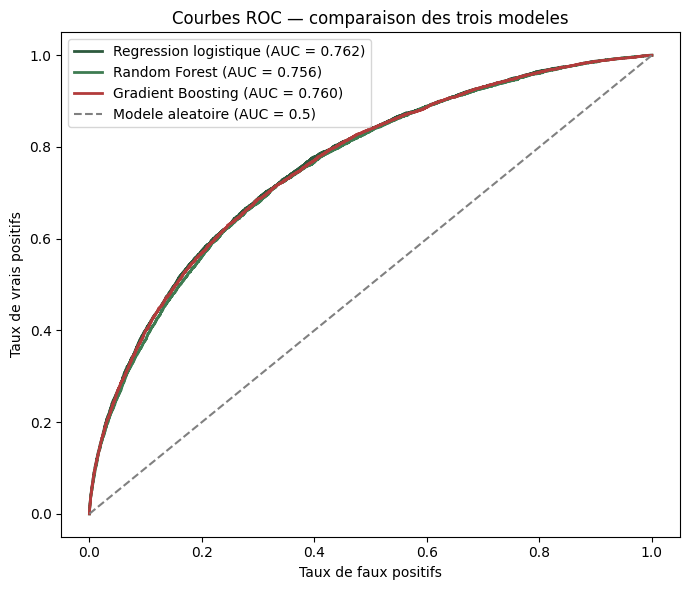

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))

for nom, proba, couleur in [
    ("Regression logistique", modele_logistique.predict_proba(X_test_scaled)[:, 1], "#2D5A3D"),
    ("Random Forest", y_proba_rf, "#3E7C52"),
    ("Gradient Boosting", y_proba_gb, "#B23B3B"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{nom} (AUC = {auc:.3f})", color=couleur, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modele aleatoire (AUC = 0.5)")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC — comparaison des trois modeles")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/courbes_roc_S7.png", dpi=150)
plt.show()

## 5. Importance des variables (Random Forest)

Contrairement à la régression logistique où chaque coefficient est directement interprétable, un Random Forest fournit un score d'**importance** par variable : à quel point chaque variable contribue-t-elle globalement aux décisions du modèle. C'est moins précis qu'un coefficient de régression, mais ça donne une idée de ce sur quoi le modèle se base.

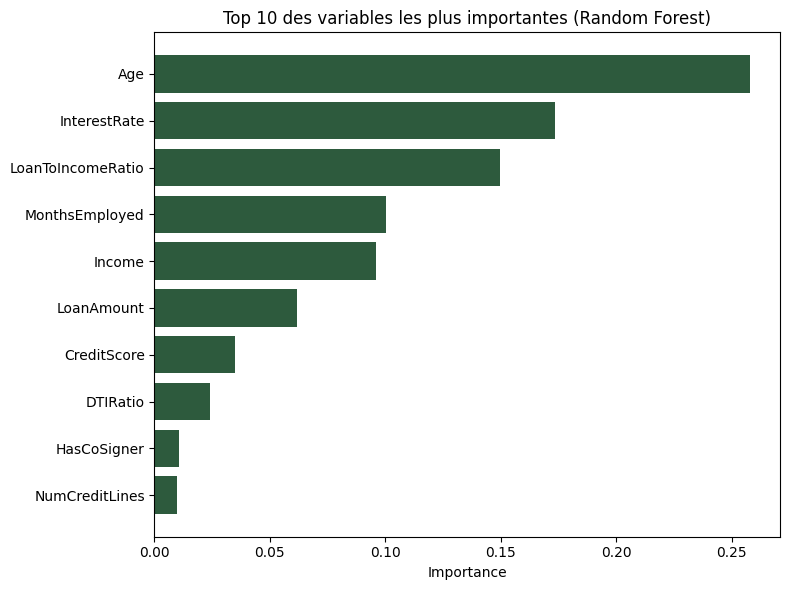

,Variable,Importance
0,Age,0.258071
6,InterestRate,0.173577
26,LoanToIncomeRatio,0.149489
4,MonthsEmployed,0.100199
1,Income,0.095991
2,LoanAmount,0.061832
3,CreditScore,0.034949
8,DTIRatio,0.023918
11,HasCoSigner,0.010501
5,NumCreditLines,0.009844


In [6]:
importance_variables = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": modele_rf.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top10 = importance_variables.head(10)
ax.barh(top10["Variable"][::-1], top10["Importance"][::-1], color="#2D5A3D")
ax.set_title("Top 10 des variables les plus importantes (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/importance_variables_S7.png", dpi=150)
plt.show()

importance_variables.head(10)

## 6. Sauvegarder les modèles et les résultats

In [7]:
import joblib

joblib.dump(modele_rf, "../src/models/random_forest.joblib")
joblib.dump(modele_gb, "../src/models/gradient_boosting.joblib")
resultats.to_csv("../reports/comparaison_modeles_S7.csv", index=False)

print("Modeles et resultats sauvegardes.")

Modeles et resultats sauvegardes.


## Résumé

- Random Forest et Gradient Boosting entraînés sur les données non standardisées (inutile pour des modèles à base d'arbres).
- Les trois modèles comparés sur AUC-ROC, recall, precision et accuracy — pas l'accuracy seule.
- Importance des variables du Random Forest analysée, pour une première lecture (moins précise qu'un coefficient de régression logistique, mais utile).
- Résultat à commenter en fonction des chiffres obtenus : est-ce que les méthodes d'ensemble apportent un vrai gain par rapport à la régression logistique, ou sont-elles équivalentes sur ce dataset (probablement synthétique, cf. S3) ?

Prochaine étape (S8) : optimisation des hyperparamètres et choix du seuil de décision final.